<a href="https://colab.research.google.com/github/devangD19/German-Credit-Risk-Prediction/blob/main/German_Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!pip install streamlit

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [32]:
df = pd.read_csv('/content/german_credit_data.csv')

In [33]:
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [35]:
df.isnull().sum()

,0
status_account,0
month_duration,0
credit_history,0
purpose,0
credit_amount,0
status_savings,0
years_employment,0
payment_to_income_ratio,0
status_and_sex,0
secondary_obligor,0


In [36]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [37]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [38]:
df.columns

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [41]:
X = df.drop('target', axis=1)
y = df['target']

In [42]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

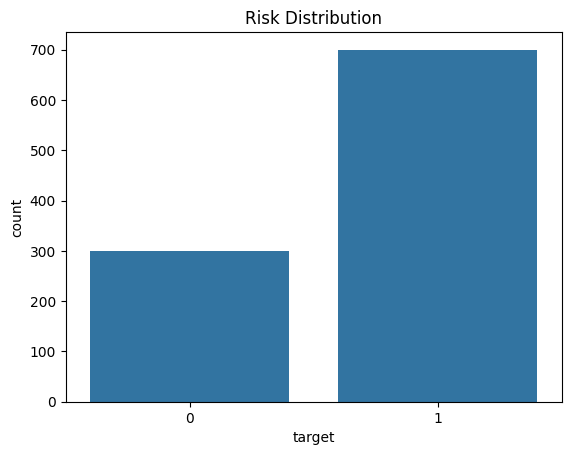

In [44]:
sns.countplot(x='target', data=df)

plt.title("Risk Distribution")
plt.show()

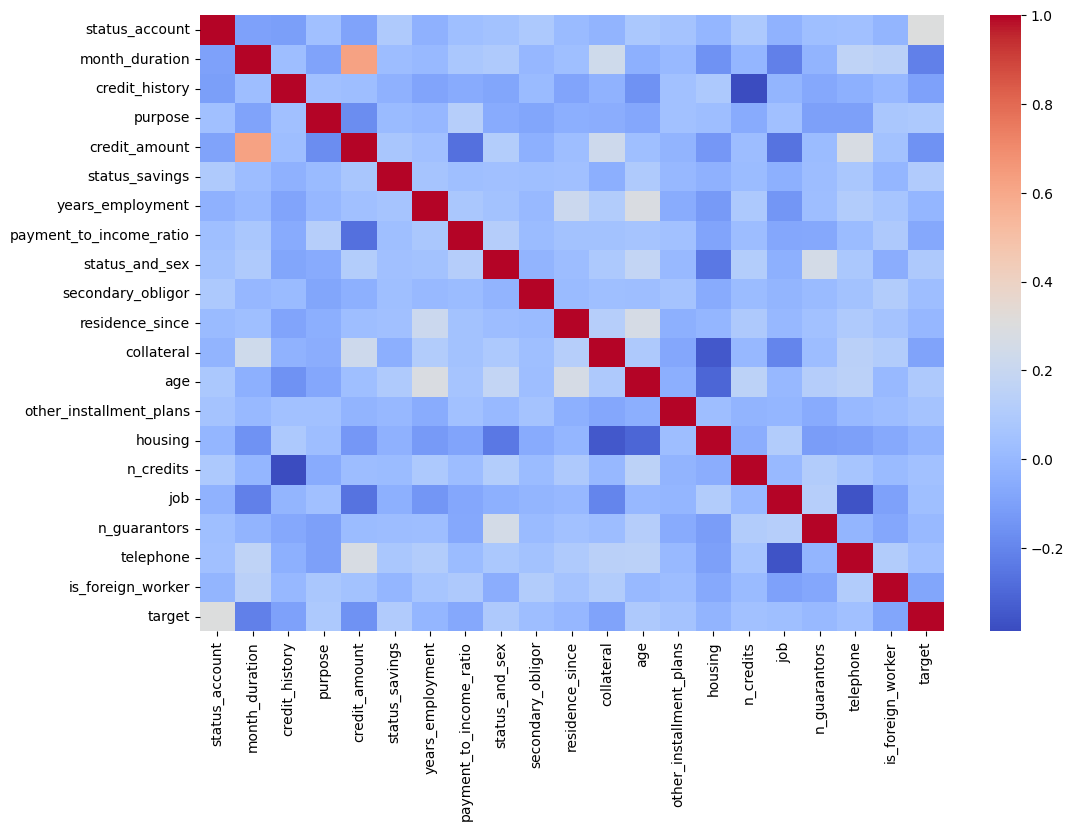

In [45]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.show()

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

Accuracy: 0.72


In [48]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

Accuracy: 0.73


In [49]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

Accuracy: 0.765


In [50]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.66      0.42      0.52        59
           1       0.79      0.91      0.84       141

    accuracy                           0.77       200
   macro avg       0.72      0.67      0.68       200
weighted avg       0.75      0.77      0.75       200



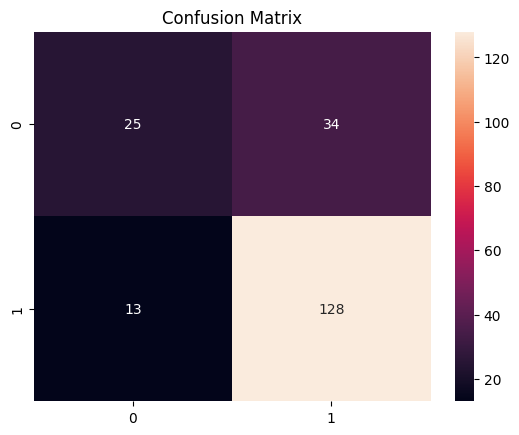

In [51]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Confusion Matrix")
plt.show()

In [52]:
roc_auc_score(y_test,
              rf.predict_proba(X_test)[:,1])

np.float64(0.7907200384661619)

In [53]:
kmeans = KMeans(n_clusters=3)

clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

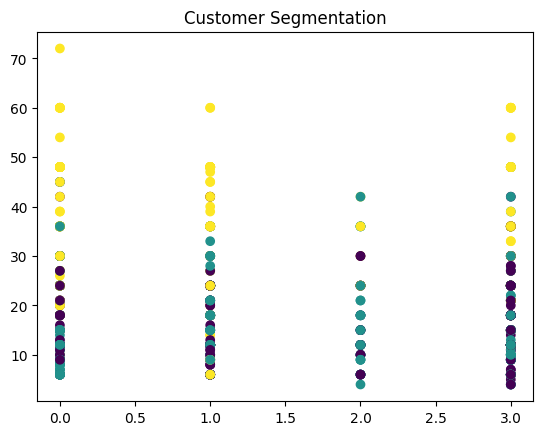

In [54]:
plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df['Cluster']
)

plt.title("Customer Segmentation")
plt.show()

In [55]:
import pickle

pickle.dump(rf,
            open('/content/credit_model.pkl', 'wb'))

In [56]:
from google.colab import files

files.download('/content/credit_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>